In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm

fname = "SL_all_p01/modes.h5"

def lm_of_n(n):
    l = int(np.floor(np.sqrt(n)))
    m = n - l*l - l
    return l, m

# Parámetros de imagen
Lbox = 5000.0
Nxy  = 600   # sube a 500 solo cuando ya estés seguro de que se ve bien

# Malla xy
x = np.linspace(-Lbox, Lbox, Nxy, dtype=np.float32)
y = np.linspace(-Lbox, Lbox, Nxy, dtype=np.float32)

X, Y = np.meshgrid(x, y, indexing="xy")
R = np.sqrt(X*X + Y*Y)
Phi = np.arctan2(Y, X)

Rflat = R.ravel()
Phiflat = Phi.ravel()

# Cargar datos una sola vez
modes = []

with h5py.File(fname, "r") as f:
    groups = sorted(
        [g for g in f.keys() if g.startswith("mode_")],
        key=lambda s: int(s.split("_")[1])
    )

    g0 = groups[0]

    if "r" in f:
        r_data = f["r"][:].astype(np.float64)
    else:
        r_data = f[g0]["vr"][:, 0].astype(np.float64)

    t_data = f[g0]["t"][:]

    valid = (Rflat >= r_data.min()) & (Rflat <= r_data.max())
    Rv = Rflat[valid]

    for g in groups:
        n = int(g.split("_")[1])
        l, m = lm_of_n(n)

        # En theta = pi/2, Y_lm = 0 si l+m es impar
        if (l + m) % 2 != 0:
            continue

        # Constante angular en theta=pi/2, phi=0
        Y0 = sph_harm(m, l, 0.0, np.pi/2)

        # Parte angular completa en el plano xy
        Ylm_v = Y0 * np.exp(1j * m * Phiflat[valid])

        # phi tiene forma {2, Nr, Nt}
        phi_all = f[g]["phi"][:].astype(np.float32)

        modes.append((l, m, phi_all, Ylm_v.astype(np.complex64)))

print("Modos usados:", [(l, m) for l, m, _, _ in modes])
print("Nt =", len(t_data), "Nr =", len(r_data))

/tmp/ipykernel_6190/4107645916.py:58: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Y0 = sph_harm(m, l, 0.0, np.pi/2)


Modos usados: [(0, 0), (1, -1), (1, 1), (2, -2), (2, 0), (2, 2), (3, -3), (3, -1), (3, 1), (3, 3), (4, -4), (4, -2), (4, 0), (4, 2), (4, 4), (5, -5), (5, -3), (5, -1), (5, 1), (5, 3), (5, 5), (6, -6), (6, -4), (6, -2), (6, 0), (6, 2), (6, 4), (6, 6), (7, -7), (7, -5), (7, -3), (7, -1), (7, 1), (7, 3), (7, 5), (7, 7), (8, -8), (8, -6), (8, -4), (8, -2), (8, 0), (8, 2), (8, 4), (8, 6), (8, 8), (9, -9), (9, -7), (9, -5), (9, -3), (9, -1), (9, 1), (9, 3), (9, 5), (9, 7), (9, 9), (10, -10), (10, -8), (10, -6), (10, -4), (10, -2), (10, 0), (10, 2), (10, 4), (10, 6), (10, 8), (10, 10), (11, -11), (11, -9), (11, -7), (11, -5), (11, -3), (11, -1), (11, 1), (11, 3), (11, 5), (11, 7), (11, 9), (11, 11), (12, -12), (12, -10), (12, -8), (12, -6), (12, -4), (12, -2), (12, 0), (12, 2), (12, 4), (12, 6), (12, 8), (12, 10), (12, 12), (13, -13), (13, -11), (13, -9), (13, -7), (13, -5), (13, -3), (13, -1), (13, 1), (13, 3), (13, 5), (13, 7), (13, 9), (13, 11), (13, 13), (14, -14), (14, -12), (14, -10), (

In [5]:
def plot_phi_xy_fast(it, part="abs"):
    field = np.zeros(Rflat.shape, dtype=np.complex64)

    for l, m, phi_all, Ylm_v in modes:
        phi_lm_r = phi_all[0, :, it] + 1j*phi_all[1, :, it]

        re = np.interp(Rv, r_data, phi_lm_r.real)
        im = np.interp(Rv, r_data, phi_lm_r.imag)

        field[valid] += (re + 1j*im).astype(np.complex64) * Ylm_v

    field = field.reshape(R.shape)

    if part == "abs":
        Q = np.abs(field)
        label = r"$|\phi|$"
    elif part == "real":
        Q = field.real
        label = r"$\mathrm{Re}(\phi)$"
    elif part == "imag":
        Q = field.imag
        label = r"$\mathrm{Im}(\phi)$"
    else:
        raise ValueError("part debe ser 'abs', 'real' o 'imag'")

    plt.figure(figsize=(6,5))

    im = plt.imshow(
        Q,
        origin="lower",
        extent=[-Lbox, Lbox, -Lbox, Lbox],
        interpolation="nearest",
        cmap="viridis"
    )

    plt.gca().set_aspect("equal")
    plt.xlabel(r"$x$")
    plt.ylabel(r"$y$")
    plt.title(fr"{label} en plano $xy$, $t={t_data[it]:.3f}$, $it={it}$")
    plt.colorbar(im, label=label)
    plt.tight_layout()
    plt.show()

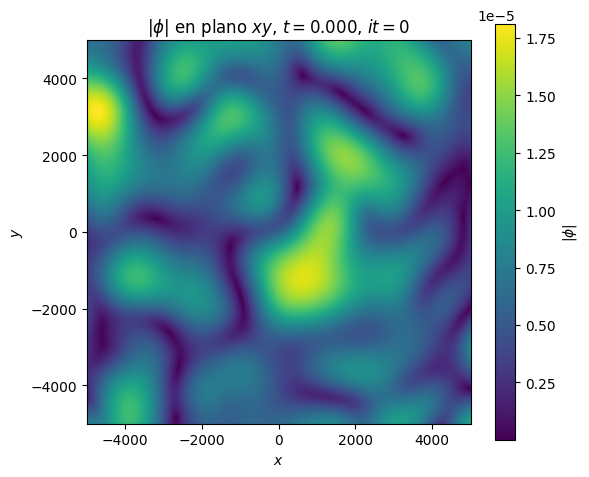

In [6]:
plot_phi_xy_fast(it=0, part="abs")

In [6]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm
from matplotlib.patches import Circle
from matplotlib.colors import LogNorm, SymLogNorm

fname = "SL_all_p001/modes.h5"

def lm_of_n(n):
    l = int(np.floor(np.sqrt(n)))
    m = n - l*l - l
    return l, m

# ------------------------------------------------------------
# Parámetros de la reconstrucción polar directa
# ------------------------------------------------------------

Rs = 1.0

# Radio interior a graficar.
# Usa Rs=1 para ocultar el interior del horizonte.
# Usa r_data.min() después de cargar si quieres mostrar hasta la excisión numérica.
r_inner_plot = Rs

# Radio exterior mostrado
Lbox = 5000.0

# Resolución angular
Nphi = 320

# Si la figura pesa mucho, usa r_stride=2, 3, 4...
# r_stride=1 usa directamente todos los puntos radiales disponibles.
r_stride = 2

# ------------------------------------------------------------
# Cargar datos
# ------------------------------------------------------------

modes = []

with h5py.File(fname, "r") as f:
    groups = sorted(
        [g for g in f.keys() if g.startswith("mode_")],
        key=lambda s: int(s.split("_")[1])
    )

    g0 = groups[0]

    if "r" in f:
        r_data = f["r"][:].astype(np.float64)
    else:
        r_data = f[g0]["vr"][:, 0].astype(np.float64)

    t_data = f[g0]["t"][:]

    r_outer_plot = min(Lbox, r_data.max())

    idx_r = np.where((r_data >= r_inner_plot) & (r_data <= r_outer_plot))[0]
    idx_r = idx_r[::r_stride]

    rp = r_data[idx_r]

    phip = np.linspace(-np.pi, np.pi, Nphi, endpoint=True, dtype=np.float64)

    RR, PP = np.meshgrid(rp, phip, indexing="ij")
    XX = RR * np.cos(PP)
    YY = RR * np.sin(PP)

    for g in groups:
        n = int(g.split("_")[1])
        l, m = lm_of_n(n)

        # En theta = pi/2, Y_lm = 0 si l+m es impar
        if (l + m) % 2 != 0:
            continue

        # Parte angular completa en el plano xy:
        # theta = pi/2, phi = phip
        Y0 = sph_harm(m, l, 0.0, np.pi/2)
        Yphi = Y0 * np.exp(1j * m * phip)

        # phi tiene forma {2, Nr, Nt}
        # Guardamos únicamente el rango radial que vamos a graficar
        phi_all = f[g]["phi"][:, idx_r, :].astype(np.float32)

        modes.append((l, m, phi_all, Yphi.astype(np.complex64)))

print("Modos usados:", [(l, m) for l, m, _, _ in modes])
print("Nt =", len(t_data))
print("Nr original =", len(r_data))
print("Nr usado para graficar =", len(rp))
print("r_inner_plot =", r_inner_plot)
print("r_outer_plot =", r_outer_plot)
print("Nphi =", Nphi)

/tmp/ipykernel_7766/3175960648.py:80: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Y0 = sph_harm(m, l, 0.0, np.pi/2)


Modos usados: [(0, 0), (1, -1), (1, 1), (2, -2), (2, 0), (2, 2), (3, -3), (3, -1), (3, 1), (3, 3), (4, -4), (4, -2), (4, 0), (4, 2), (4, 4), (5, -5), (5, -3), (5, -1), (5, 1), (5, 3), (5, 5), (6, -6), (6, -4), (6, -2), (6, 0), (6, 2), (6, 4), (6, 6), (7, -7), (7, -5), (7, -3), (7, -1), (7, 1), (7, 3), (7, 5), (7, 7), (8, -8), (8, -6), (8, -4), (8, -2), (8, 0), (8, 2), (8, 4), (8, 6), (8, 8), (9, -9), (9, -7), (9, -5), (9, -3), (9, -1), (9, 1), (9, 3), (9, 5), (9, 7), (9, 9), (10, -10), (10, -8), (10, -6), (10, -4), (10, -2), (10, 0), (10, 2), (10, 4), (10, 6), (10, 8), (10, 10), (11, -11), (11, -9), (11, -7), (11, -5), (11, -3), (11, -1), (11, 1), (11, 3), (11, 5), (11, 7), (11, 9), (11, 11), (12, -12), (12, -10), (12, -8), (12, -6), (12, -4), (12, -2), (12, 0), (12, 2), (12, 4), (12, 6), (12, 8), (12, 10), (12, 12), (13, -13), (13, -11), (13, -9), (13, -7), (13, -5), (13, -3), (13, -1), (13, 1), (13, 3), (13, 5), (13, 7), (13, 9), (13, 11), (13, 13), (14, -14), (14, -12), (14, -10), (

In [7]:
def reconstruct_phi_xy_polar_direct(it):
    """
    Reconstruye phi(t,x,y) usando directamente la malla radial rp,
    sin interpolación radial.

    Devuelve:
        field con shape (Nr_plot, Nphi)
    """
    field = np.zeros((len(rp), len(phip)), dtype=np.complex64)

    for l, m, phi_all, Yphi in modes:
        phi_lm_r = phi_all[0, :, it] + 1j * phi_all[1, :, it]

        field += phi_lm_r[:, None].astype(np.complex64) * Yphi[None, :]

    return field


def plot_phi_xy_polar_direct(
    it,
    part="abs",
    log_abs=False,
    sym_log=False,
    cmap_name="viridis",
    percentile_vmin=1.0,
    percentile_vmax=99.8,
    linthresh=1e-6,
    draw_outer_circle=True,
    draw_inner_circle=True
):
    """
    Grafica la reconstrucción polar directa en el plano xy.

    Parámetros
    ----------
    it : int
        Índice temporal.

    part : str
        "abs", "real" o "imag".

    log_abs : bool
        Si part="abs", usa escala logarítmica y evita que ceros numéricos
        contaminen la barra de color.

    sym_log : bool
        Si part="real" o part="imag", usa escala simétrica logarítmica.

    cmap_name : str
        Colormap.

    percentile_vmin, percentile_vmax : float
        Percentiles para fijar límites de color de forma robusta.

    linthresh : float
        Umbral lineal para SymLogNorm en partes real/imaginaria.
    """

    field = reconstruct_phi_xy_polar_direct(it)

    if part == "abs":
        Q = np.abs(field)
        label = r"$|\phi|$"
    elif part == "real":
        Q = field.real
        label = r"$\mathrm{Re}(\phi)$"
    elif part == "imag":
        Q = field.imag
        label = r"$\mathrm{Im}(\phi)$"
    else:
        raise ValueError("part debe ser 'abs', 'real' o 'imag'")

    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad("white")

    norm = None

    if part == "abs":
        if log_abs:
            positive = Q[np.isfinite(Q) & (Q > 0)]

            if len(positive) == 0:
                raise ValueError("No hay valores positivos para usar LogNorm.")

            vmin = np.percentile(positive, percentile_vmin)
            vmax = np.percentile(positive, percentile_vmax)

            Q = np.where(Q >= vmin, Q, np.nan)
            norm = LogNorm(vmin=vmin, vmax=vmax)

        else:
            finite = Q[np.isfinite(Q)]
            vmin = np.percentile(finite, percentile_vmin)
            vmax = np.percentile(finite, percentile_vmax)

    else:
        finite = Q[np.isfinite(Q)]

        if sym_log:
            vmax = np.percentile(np.abs(finite), percentile_vmax)
            vmin = -vmax
            norm = SymLogNorm(
                linthresh=linthresh,
                vmin=vmin,
                vmax=vmax
            )
        else:
            vmax = np.percentile(np.abs(finite), percentile_vmax)
            vmin = -vmax

    Qplot = np.ma.masked_invalid(Q)

    fig, ax = plt.subplots(figsize=(6.4, 5.6))

    if norm is None:
        im = ax.pcolormesh(
            XX,
            YY,
            Qplot,
            shading="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax
        )
    else:
        im = ax.pcolormesh(
            XX,
            YY,
            Qplot,
            shading="auto",
            cmap=cmap,
            norm=norm
        )

    ax.set_aspect("equal")
    ax.set_xlim(-r_outer_plot, r_outer_plot)
    ax.set_ylim(-r_outer_plot, r_outer_plot)

    if draw_outer_circle:
        ax.add_patch(
            Circle(
                (0.0, 0.0),
                r_outer_plot,
                fill=False,
                color="k",
                linewidth=1.2,
                zorder=5
            )
        )

    if draw_inner_circle:
        ax.add_patch(
            Circle(
                (0.0, 0.0),
                r_inner_plot,
                facecolor="black",
                edgecolor="black",
                linewidth=1.0,
                zorder=6
            )
        )

    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_title(fr"{label} en plano $xy$, $t={t_data[it]:.3f}$")

    plt.colorbar(im, ax=ax, label=label)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_7766/2645486956.py:116: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


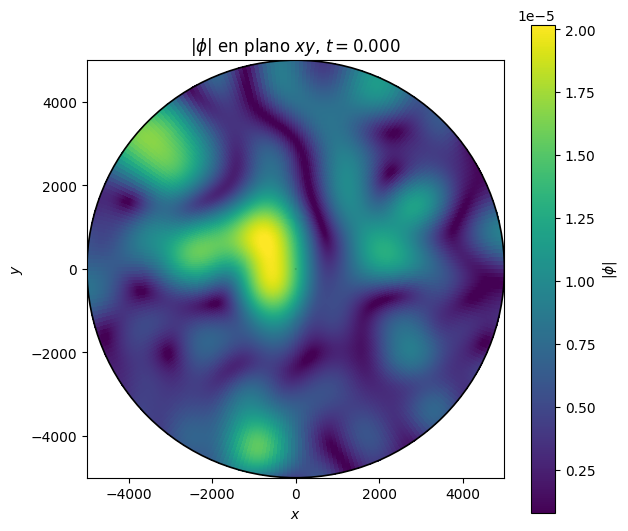

In [8]:
plot_phi_xy_polar_direct(it=0, part="abs", log_abs=False)

In [12]:
# Cell — Movie polar direct: sin huecos de fondo y sin última instantánea

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from matplotlib.colors import LogNorm, SymLogNorm
from matplotlib.patches import Circle
from IPython.display import Video, Image, display
import shutil
import os


# ============================================================
# Parámetros de la película
# ============================================================

part = "abs"          # "abs", "real", "imag"
log_abs = True        # solo para part="abs"
sym_log = False       # solo para part="real" o "imag"

cmap_name = "viridis"

percentile_vmin = 1.0
percentile_vmax = 99.8
linthresh = 1e-6

fps = 12
dpi = 140

FRAME_STRIDE = 1

# Más parecido a tu función original:
# True  = recalcula vmin/vmax en cada snapshot
# False = usa una escala global fija para toda la película
USE_FRAME_LOCAL_SCALE = True

draw_outer_circle = True
draw_inner_circle = True

output_basename = "phi_xy_polar_direct_movie"


# ============================================================
# Lista de snapshots
# ============================================================

# Excluye la última instantánea porque aparece vacía
frames = np.arange(0, len(t_data) - 1, FRAME_STRIDE, dtype=int)

if len(frames) == 0:
    raise ValueError("No hay frames disponibles después de excluir la última instantánea.")

print(f"Generando película con {len(frames)} snapshots.")
print(f"Último snapshot incluido: it = {frames[-1]}, t = {t_data[frames[-1]]:.6f}")


# ============================================================
# Funciones auxiliares
# ============================================================

def quantity_from_field(field, part):
    if part == "abs":
        return np.abs(field), r"$|\phi|$"
    elif part == "real":
        return field.real, r"$\mathrm{Re}(\phi)$"
    elif part == "imag":
        return field.imag, r"$\mathrm{Im}(\phi)$"
    else:
        raise ValueError("part debe ser 'abs', 'real' o 'imag'")


def get_limits(Q, part):
    """
    Calcula vmin/vmax de forma robusta, parecida a tu función original.
    """
    if part == "abs":
        if log_abs:
            vals = Q[np.isfinite(Q) & (Q > 0)]

            if vals.size == 0:
                raise ValueError("No hay valores positivos para usar LogNorm.")

            vmin = np.percentile(vals, percentile_vmin)
            vmax = np.percentile(vals, percentile_vmax)

            if vmin <= 0:
                vmin = vals.min()

            if vmax <= vmin:
                vmax = vals.max()

            if vmax <= vmin:
                vmax = vmin * 1.01

        else:
            vals = Q[np.isfinite(Q)]

            if vals.size == 0:
                raise ValueError("No hay valores finitos para graficar.")

            vmin = np.percentile(vals, percentile_vmin)
            vmax = np.percentile(vals, percentile_vmax)

            if vmax <= vmin:
                vmax = vmin + 1e-30

    else:
        vals = Q[np.isfinite(Q)]

        if vals.size == 0:
            raise ValueError("No hay valores finitos para graficar.")

        vmax = np.percentile(np.abs(vals), percentile_vmax)

        if vmax <= 0:
            vmax = np.max(np.abs(vals))

        if vmax <= 0:
            vmax = 1e-30

        vmin = -vmax

    return vmin, vmax


def make_norm(part, vmin, vmax):
    if part == "abs" and log_abs:
        return LogNorm(vmin=vmin, vmax=vmax)

    if part in ("real", "imag") and sym_log:
        return SymLogNorm(
            linthresh=linthresh,
            vmin=vmin,
            vmax=vmax
        )

    return None


def prepare_quantity_for_plot(Q, part, vmin, vmax):
    """
    Evita huecos blancos:
    - En escala logarítmica, valores <= 0 o muy pequeños se ponen en vmin.
    - No se convierten a NaN salvo que realmente sean no finitos.
    """
    Q = np.asarray(Q).copy()

    if part == "abs" and log_abs:
        finite = np.isfinite(Q)

        # Los valores no positivos no pueden entrar a LogNorm.
        # En vez de enmascararlos, los saturamos al color mínimo.
        Q[finite & (Q <= 0)] = vmin

        # Los valores menores que vmin se pintan con el color mínimo.
        Q[finite] = np.clip(Q[finite], vmin, vmax)

        # Solo se enmascaran valores realmente no finitos.
        return np.ma.masked_invalid(Q)

    else:
        finite = np.isfinite(Q)
        Q[finite] = np.clip(Q[finite], vmin, vmax)
        return np.ma.masked_invalid(Q)


# ============================================================
# Escala global opcional
# ============================================================

global_vmin = None
global_vmax = None

if not USE_FRAME_LOCAL_SCALE:
    values_for_norm = []

    for it in frames:
        field = reconstruct_phi_xy_polar_direct(it)
        Q, label = quantity_from_field(field, part)

        if part == "abs" and log_abs:
            vals = Q[np.isfinite(Q) & (Q > 0)]
        elif part in ("real", "imag"):
            vals = np.abs(Q[np.isfinite(Q)])
        else:
            vals = Q[np.isfinite(Q)]

        if vals.size > 0:
            values_for_norm.append(vals.ravel())

    if len(values_for_norm) == 0:
        raise ValueError("No hay valores para estimar la normalización global.")

    values_for_norm = np.concatenate(values_for_norm)

    if part == "abs":
        if log_abs:
            global_vmin = np.percentile(values_for_norm, percentile_vmin)
            global_vmax = np.percentile(values_for_norm, percentile_vmax)

            if global_vmin <= 0:
                positive = values_for_norm[values_for_norm > 0]
                global_vmin = positive.min()
        else:
            global_vmin = np.percentile(values_for_norm, percentile_vmin)
            global_vmax = np.percentile(values_for_norm, percentile_vmax)
    else:
        global_vmax = np.percentile(values_for_norm, percentile_vmax)
        global_vmin = -global_vmax

    print(f"Escala global: vmin = {global_vmin:.6e}, vmax = {global_vmax:.6e}")


# ============================================================
# Crear figura inicial
# ============================================================

cmap = plt.get_cmap(cmap_name).copy()
cmap.set_bad("white")

fig, ax = plt.subplots(figsize=(6.4, 5.6))

it0 = frames[0]
field0 = reconstruct_phi_xy_polar_direct(it0)
Q0, label = quantity_from_field(field0, part)

if USE_FRAME_LOCAL_SCALE:
    vmin, vmax = get_limits(Q0, part)
else:
    vmin, vmax = global_vmin, global_vmax

norm = make_norm(part, vmin, vmax)
Q0_plot = prepare_quantity_for_plot(Q0, part, vmin, vmax)

if norm is None:
    im = ax.pcolormesh(
        XX,
        YY,
        Q0_plot,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )
else:
    im = ax.pcolormesh(
        XX,
        YY,
        Q0_plot,
        shading="auto",
        cmap=cmap,
        norm=norm
    )

ax.set_aspect("equal")
ax.set_xlim(-r_outer_plot, r_outer_plot)
ax.set_ylim(-r_outer_plot, r_outer_plot)

if draw_outer_circle:
    ax.add_patch(
        Circle(
            (0.0, 0.0),
            r_outer_plot,
            fill=False,
            color="k",
            linewidth=1.2,
            zorder=5
        )
    )

if draw_inner_circle:
    ax.add_patch(
        Circle(
            (0.0, 0.0),
            r_inner_plot,
            facecolor="black",
            edgecolor="black",
            linewidth=1.0,
            zorder=6
        )
    )

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")

title = ax.set_title(fr"{label} en plano $xy$, $t={t_data[it0]:.3f}$")

cbar = plt.colorbar(im, ax=ax, label=label)

plt.tight_layout()


# ============================================================
# Función de actualización
# ============================================================

def update(frame_number):
    it = frames[frame_number]

    field = reconstruct_phi_xy_polar_direct(it)
    Q, _ = quantity_from_field(field, part)

    if USE_FRAME_LOCAL_SCALE:
        vmin, vmax = get_limits(Q, part)
        norm = make_norm(part, vmin, vmax)
        Qplot = prepare_quantity_for_plot(Q, part, vmin, vmax)

        im.set_norm(norm)

        if norm is None:
            im.set_clim(vmin, vmax)

        cbar.update_normal(im)

    else:
        vmin, vmax = global_vmin, global_vmax
        Qplot = prepare_quantity_for_plot(Q, part, vmin, vmax)

    im.set_array(Qplot.ravel())

    title.set_text(fr"{label} en plano $xy$, $t={t_data[it]:.3f}$")

    return im, title


# ============================================================
# Crear animación
# ============================================================

anim = animation.FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=1000 / fps,
    blit=False
)

plt.close(fig)


# ============================================================
# Guardar y desplegar
# ============================================================

if shutil.which("ffmpeg") is not None:
    out_file = output_basename + ".mp4"

    writer = animation.FFMpegWriter(
        fps=fps,
        bitrate=2400
    )

    anim.save(out_file, writer=writer, dpi=dpi)

    print(f"Película guardada en: {os.path.abspath(out_file)}")
    display(Video(out_file, embed=True))

else:
    out_file = output_basename + ".gif"

    writer = animation.PillowWriter(fps=fps)
    anim.save(out_file, writer=writer, dpi=dpi)

    print(f"GIF guardado en: {os.path.abspath(out_file)}")
    display(Image(filename=out_file))

Generando película con 120 snapshots.
Último snapshot incluido: it = 119, t = 29751.904000


/tmp/ipykernel_22021/2698318504.py:247: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


Película guardada en: /home/flavio/Codes/KG-Y/phi_xy_polar_direct_movie.mp4


In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt


def n_of_lm(ell, m):
    """
    Inversa de:
        ell = floor(sqrt(n))
        m = n - ell^2 - ell

    Entonces:
        n = ell^2 + ell + m
    """
    return ell*ell + ell + m


def find_group_for_lm(f, ell_target, m_target):
    """
    Busca el grupo mode_XXXXX correspondiente a un ell,m.
    """
    n_target = n_of_lm(ell_target, m_target)

    # Primero intenta con formato estándar
    candidates = [
        f"mode_{n_target:05d}",
        f"mode_{n_target:04d}",
        f"mode_{n_target}"
    ]

    for gname in candidates:
        if gname in f:
            return gname

    # Si no lo encuentra, busca recorriendo todos los grupos
    for gname in f.keys():
        if not gname.startswith("mode_"):
            continue

        n = int(gname.split("_")[1])
        ell, m = lm_of_n(n)

        if ell == ell_target and m == m_target:
            return gname

    raise KeyError(f"No encontré el modo ell={ell_target}, m={m_target}, n={n_target}")


def read_complex_mode_dataset(g, var):
    """
    Lee un dataset complejo guardado como:
        var shape = (2, Nr, Nt)
    o complejo nativo.
    """
    if var not in g:
        raise KeyError(f"No existe '{var}' en {g.name}. Datasets disponibles: {list(g.keys())}")

    A = g[var][:]

    if np.iscomplexobj(A):
        return A

    # Caso esperado en tu archivo: (2, Nr, Nt)
    if A.ndim == 3 and A.shape[0] == 2:
        return A[0, :, :] + 1j*A[1, :, :]

    # Caso alternativo: (Nr, Nt, 2)
    if A.ndim == 3 and A.shape[-1] == 2:
        return A[:, :, 0] + 1j*A[:, :, 1]

    raise ValueError(f"Formato inesperado para {g.name}/{var}: shape={A.shape}")


def plot_lm_1d(
    fname,
    ell,
    m,
    i=1,
    vars_to_plot=("phi", "psi", "pi"),
    rlim=(0.45, 5.0),
    logy=True,
    normalize=False,
    abs_only=True,
):
    """
    Grafica perfiles radiales 1D de un modo específico (ell,m).

    Parámetros:
        fname        : archivo HDF5
        ell, m       : modo deseado
        i            : índice temporal
        vars_to_plot : variables a graficar, por ejemplo ("phi", "psi", "pi")
        rlim         : límites radiales
        logy         : escala logarítmica para |campo|
        normalize    : normaliza cada perfil por su máximo
        abs_only     : si True grafica |campo|; si False grafica Re, Im y |campo|
    """

    with h5py.File(fname, "r") as f:

        gname = find_group_for_lm(f, ell, m)
        g = f[gname]

        if "r" in f:
            r = f["r"][:]
        elif "vr" in g:
            r = g["vr"][:, 0]
        else:
            raise KeyError("No encontré r en el archivo ni vr en el grupo.")

        if "t" in g:
            t = g["t"][:]
        elif "t" in f:
            t = f["t"][:]
        else:
            t = None

        if t is not None:
            time_label = fr"$t={t[i]:.6g}$"
        else:
            time_label = fr"$i={i}$"

        print(f"Graficando grupo: {gname}")
        print(f"Modo: ell={ell}, m={m}, n={n_of_lm(ell,m)}")
        print(f"Tiempo: {time_label}")

        for var in vars_to_plot:

            A = read_complex_mode_dataset(g, var)

            if A.ndim != 2:
                raise ValueError(f"Esperaba {var} con shape (Nr,Nt), llegó {A.shape}")

            if i >= A.shape[1]:
                raise IndexError(f"i={i} fuera de rango para {var}. Nt={A.shape[1]}")

            prof = A[:, i]
            amp = np.abs(prof)

            max_amp = np.nanmax(amp)
            idx_max = np.nanargmax(amp)
            r_max = r[idx_max]

            print(f"{var}: max |{var}| = {max_amp:.6e} en r = {r_max:.6e}")

            if abs_only:
                y = amp.copy()

                if normalize and max_amp > 0:
                    y = y / max_amp

                if logy:
                    y = np.maximum(y, 1e-300)

                plt.figure(figsize=(8, 4.5))
                plt.plot(r, y, lw=1.4)

                plt.axvline(1.0, color="k", ls="--", lw=1.0, label=r"$R_s$")
                plt.axvline(r[0], color="gray", ls=":", lw=1.0, label=r"$r_{\min}$")

                plt.xlim(*rlim)
                plt.xlabel(r"$r/R_s$")

                if normalize:
                    plt.ylabel(fr"$|{var}_{{\ell m}}|/\max |{var}_{{\ell m}}|$")
                else:
                    plt.ylabel(fr"$|{var}_{{\ell m}}|$")

                plt.title(fr"$|{var}_{{\ell m}}(r)|$, $\ell={ell}$, $m={m}$, {time_label}")

                if logy:
                    plt.yscale("log")

                plt.grid(alpha=0.25)
                plt.legend()
                plt.tight_layout()
                plt.show()

            else:
                plt.figure(figsize=(8, 4.5))

                plt.plot(r, np.real(prof), lw=1.2, label=fr"$\mathrm{{Re}}({var})$")
                plt.plot(r, np.imag(prof), lw=1.2, label=fr"$\mathrm{{Im}}({var})$")
                plt.plot(r, amp, lw=1.4, color="k", label=fr"$|{var}|$")

                plt.axvline(1.0, color="k", ls="--", lw=1.0, alpha=0.7)
                plt.axvline(r[0], color="gray", ls=":", lw=1.0)

                plt.xlim(*rlim)
                plt.xlabel(r"$r/R_s$")
                plt.ylabel(fr"${var}_{{\ell m}}$")
                plt.title(fr"${var}_{{\ell m}}(r)$, $\ell={ell}$, $m={m}$, {time_label}")

                plt.grid(alpha=0.25)
                plt.legend()
                plt.tight_layout()
                plt.show()

Graficando grupo: mode_00000
Modo: ell=0, m=0, n=0
Tiempo: $t=20001.3$
phi: max |phi| = 4.689231e-05 en r = 5.000000e-01


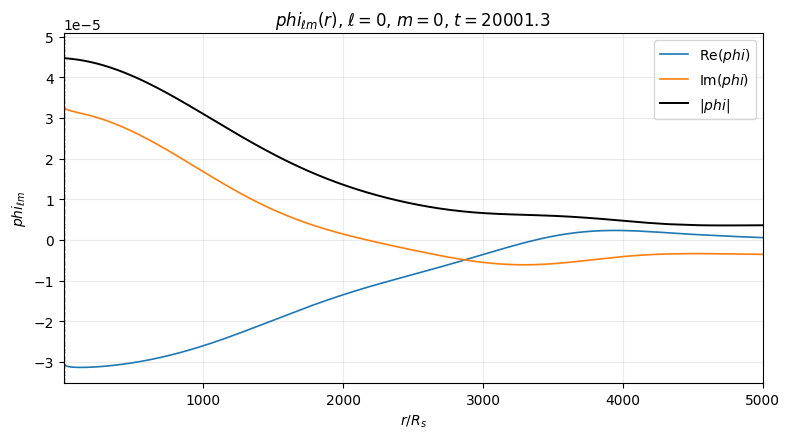

pi: max |pi| = 1.678223e-06 en r = 5.000000e-01


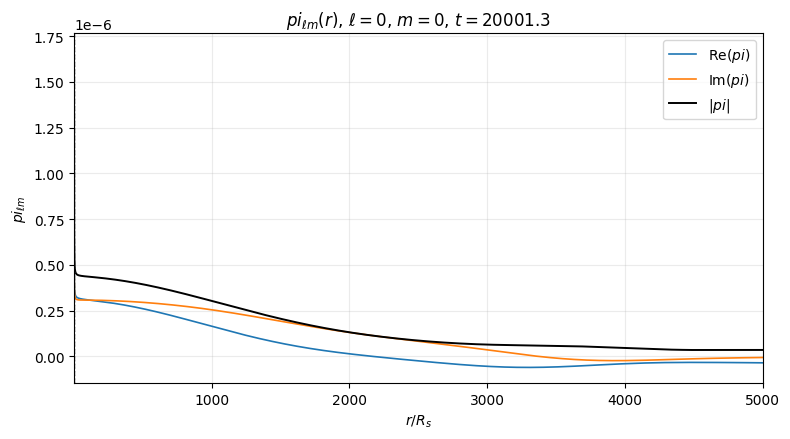

Graficando grupo: mode_00000
Modo: ell=0, m=0, n=0
Tiempo: $t=0$
phi: max |phi| = 5.130323e-05 en r = 5.000000e-01


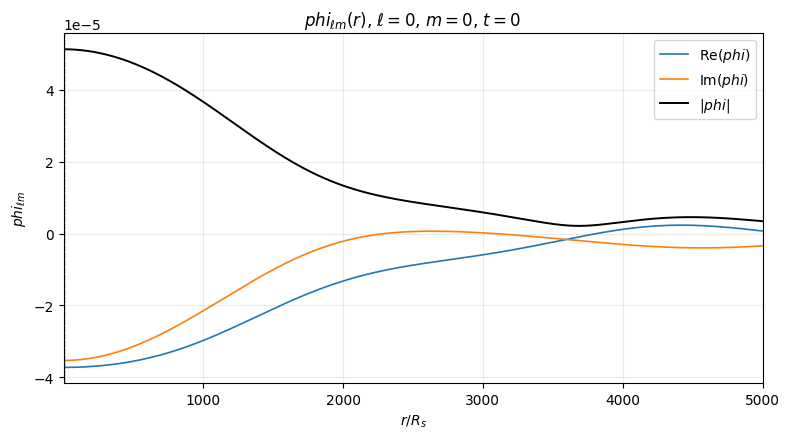

pi: max |pi| = 5.039823e-07 en r = 5.000000e-01


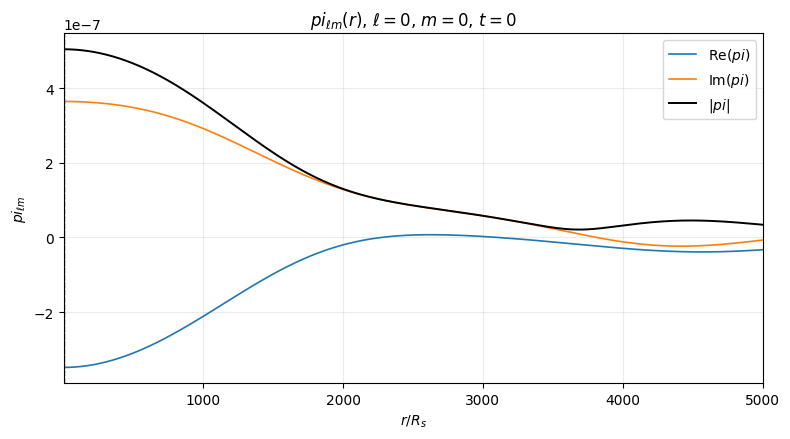

In [9]:
plot_lm_1d(
    fname,
    ell=0,
    m=0,
    i=80,
    vars_to_plot=("phi", "pi"),
    rlim=(0.5, 5000.0),
    logy=False,
    normalize=False,
    abs_only=False
)

plot_lm_1d(
    fname,
    ell=0,
    m=0,
    i=0,
    vars_to_plot=("phi", "pi"),
    rlim=(0.5, 5000.0),
    logy=False,
    normalize=False,
    abs_only=False
)

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

H5FILE = "SL_all_p001/modes.h5"


def n_to_ellm(n):
    ell = int(np.sqrt(n))
    r = n - ell * ell
    m = int(r) - ell
    return ell, m


def ellm_to_n(ell, m):
    if abs(m) > ell:
        raise ValueError(f"Modo inválido: ell={ell}, m={m}. Debe cumplirse |m| <= ell.")
    return ell*ell + ell + m


def mode_group_name(n):
    return f"mode_{n:05d}"


def ellm_group_name(ell, m):
    return mode_group_name(ellm_to_n(ell, m))